Params: {'colsample_bytree': 0.6271057697405685, 'learning_rate': 0.1, 'max_depth': 3, 'alpha': 0.01, 'eval_metric': 'rmse'}
Train R²: 0.9993564276874174
Test  R²: 0.9778871431913364
Train Pearson: 0.9997205726450885
Test  Pearson: 0.9891295926004391
Train RMSE   : 0.0064395505675420815
Test  RMSE   : 0.040433140926074584


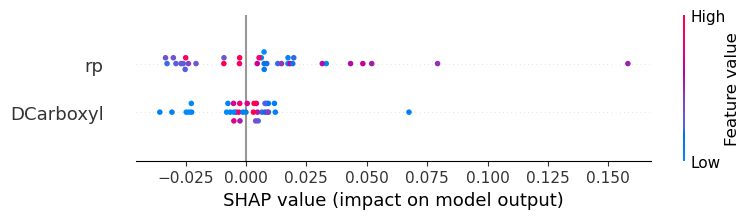

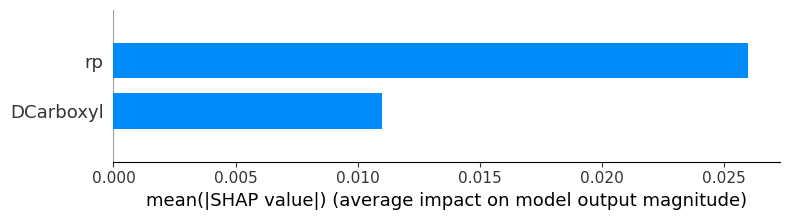

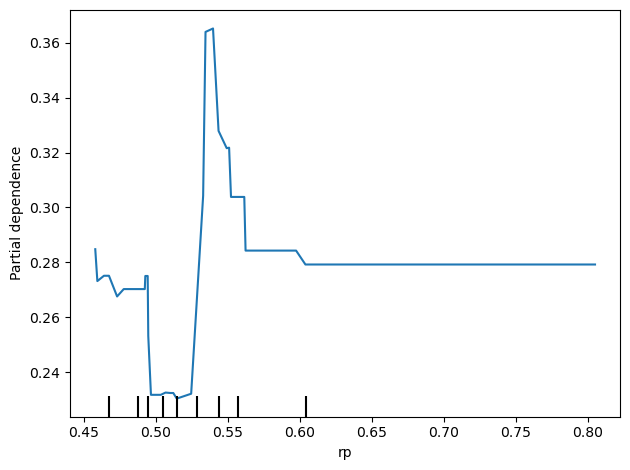

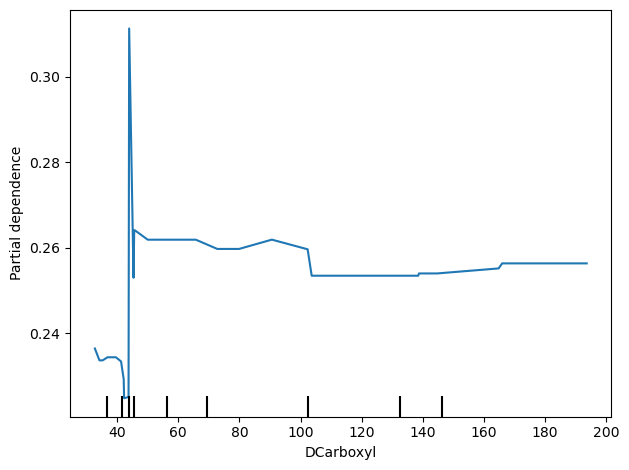

In [5]:
import os
import time
import numpy as np
import pandas as pd
from rdkit import Chem
from scipy.stats import pearsonr
from sklearn import metrics
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from xgboost import XGBRegressor
from bayes_opt import BayesianOptimization
import shap
import matplotlib.pyplot as plt

# =====================================================================
# 1. Load dataset
# =====================================================================
# Note: this dataset must be obtained from the experimental data
datasets = pd.read_excel('structure - H2O MgCl2.xlsx')

X = datasets.iloc[:, 0:8].to_numpy()
y = datasets.iloc[:, 8]

# =====================================================================
# 2. Train/test split (test set is used only for final evaluation)
# =====================================================================
start_time = time.time()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=329
)

history = []


# =====================================================================
# 3. Objective function for Bayesian Optimization
# =====================================================================
def xgb_cv(colsample_bytree, learning_rate, max_depth, alpha):
    params = {
        'colsample_bytree': float(np.clip(colsample_bytree, 0.1, 1.0)),
        'learning_rate':    float(np.clip(learning_rate,    0.01, 0.3)),
        'max_depth':        int(max_depth),
        'alpha':            float(np.clip(alpha,            0.01, 10)),
        'eval_metric':      'rmse'
    }

    model = XGBRegressor(**params, n_estimators=300)

    # 5-fold cross-validation R^2 on the training set
    scores = cross_val_score(model, X_train, y_train,
                             scoring='r2', cv=5, n_jobs=-1)
    cv_mean = scores.mean()

    # Fit on full training set to record train/test R^2 for later inspection
    model.fit(X_train, y_train)
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2  = r2_score(y_test,  model.predict(X_test))

    # Discard pathological cases where training fits worse than test
    if train_r2 < test_r2:
        cv_mean = -10000

    history.append({
        'params':  params,
        'cv_mean': cv_mean,
        'test_r2': test_r2
    })

    # BO objective: maximize CV mean R^2
    return cv_mean


# =====================================================================
# 4. Search space
# =====================================================================
param_bounds = {
    'colsample_bytree': (0.1, 1.0),
    'learning_rate':    (0.1, 0.3),
    'max_depth':        (1,   10),
    'alpha':            (0.01, 10)
}

# =====================================================================
# 5. Run Bayesian Optimization (silent mode)
# =====================================================================
optimizer = BayesianOptimization(
    f=xgb_cv,
    pbounds=param_bounds,
    random_state=0,
    verbose=0
)

optimizer.maximize(init_points=50, n_iter=450)

# =====================================================================
# 6. Select final hyperparameters
#    Among all candidates whose CV mean is within 0.1 of the best,
#    pick the one with the highest test R^2.
# =====================================================================
best_cv  = max(h['cv_mean'] for h in history)
filtered = [h for h in history if (best_cv - h['cv_mean']) <= 0.1]

best_choice = max(filtered, key=lambda h: h['test_r2'])

# =====================================================================
# 7. Train the final model with the chosen hyperparameters
# =====================================================================
final_params = best_choice['params']
final_model  = XGBRegressor(**final_params, n_estimators=300)
final_model.fit(X_train, y_train)

y_train_pred = final_model.predict(X_train)
y_test_pred  = final_model.predict(X_test)

# ---------- Output: final selected parameters and final model performance ----------
print("Params:", final_params)
print("Train R\u00b2:", r2_score(y_train, y_train_pred))
print("Test  R\u00b2:", r2_score(y_test,  y_test_pred))

# =====================================================================
# 8. Pearson correlation and RMSE 
# =====================================================================
pearson_train, _ = pearsonr(y_train, y_train_pred)
pearson_test,  _ = pearsonr(y_test,  y_test_pred)

rmse_train = np.sqrt(metrics.mean_squared_error(y_train, y_train_pred))
rmse_test  = np.sqrt(metrics.mean_squared_error(y_test,  y_test_pred))

print("Train Pearson:", pearson_train)
print("Test  Pearson:", pearson_test)
print("Train RMSE   :", rmse_train)
print("Test  RMSE   :", rmse_test)

# =====================================================================
# 9. Export predictions to Excel
# =====================================================================
output_dir = 'results'
os.makedirs(output_dir, exist_ok=True)

results_train = pd.DataFrame({
    'Actual':    y_train,
    'Predicted': y_train_pred
})
results_test = pd.DataFrame({
    'Actual':    y_test,
    'Predicted': y_test_pred
})

predictions_path = os.path.join(output_dir, 'structure_H2O_MgCl2_predictions.xlsx')
with pd.ExcelWriter(predictions_path) as writer:
    results_train.to_excel(writer, sheet_name='Train', index=False)
    results_test.to_excel(writer,  sheet_name='Test',  index=False)

# =====================================================================
# 10. SHAP analysis (top-2 features)
# =====================================================================
feature_names = datasets.columns[:8]
X_train_df    = pd.DataFrame(X_train, columns=feature_names)

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_train_df)

top2_features    = feature_names[:2]
X_train_top2     = X_train_df[top2_features]
shap_values_top2 = shap_values[:, :2]

# Beeswarm plot
shap.summary_plot(shap_values_top2, X_train_top2,
                  feature_names=top2_features)

# Bar plot
shap.summary_plot(shap_values_top2, X_train_top2,
                  feature_names=top2_features, plot_type='bar')


# =====================================================================
# 11. Partial Dependence Plots (PDP) and export
# =====================================================================
def export_pdp(model, X_train_df, feature_name, output_dir):
    """Compute the PDP for a single feature, export it to Excel, and plot it."""
    if feature_name not in X_train_df.columns:
        raise ValueError(
            f"The feature '{feature_name}' is not present in the DataFrame columns."
        )

    disp = PartialDependenceDisplay.from_estimator(
        estimator=model,
        X=X_train_df,
        features=[feature_name],
        kind='average'
    )

    # Extract the line data (x, y) for export
    line   = disp.lines_[0][0]
    x_vals = line.get_xdata()
    y_vals = line.get_ydata()

    pdp_df = pd.DataFrame({
        feature_name.strip():  x_vals,
        'Partial Dependence':  y_vals
    })

    output_filename = os.path.join(
        output_dir, f'pdp_structure_H2O_MgCl2_{feature_name}.xlsx'
    )
    pdp_df.to_excel(output_filename, index=False)

    plt.tight_layout()
    plt.show()


# Make sure X_train is a DataFrame with proper column names
if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train, columns=feature_names)

export_pdp(final_model, X_train, 'rp',        output_dir)
export_pdp(final_model, X_train, 'DCarboxyl', output_dir)